# Validate Paul's 52Y E-field results

Target: **Left STN** (Allen atlas acronym `STH`). Non-targets: Right STN, Left/Right M1 (`PrCG`).

Montage (from `Paul_Validation_E_Fields/52Y/README.txt`):
```
i1: AF4-FT9, 1.69 mA
i2: P9-CP2,  1.89 mA
```

Electrode positions are Paul's neuronavigation-recorded coordinates in `electrode_positions/electrode_position_52Y0X_ras`
(confirmed to match SimNIBS subject-space RAS convention against charm's own Jurak 10-10 scalp positions).

Subjects: 52Y03, 52Y04, 52Y05 (52Y02 skipped — missing `_ras` electrode file).

Run with SimNIBS's own python: `~/SimNIBS-4.6/simnibs_env/python.exe`

## Step 0: setup

In [4]:
%load_ext autoreload
%autoreload 2
# (Force reload of all modules before executing code)
import os
import numpy as np
import nibabel as nib
from scipy.ndimage import map_coordinates

PROJECT_DIR = r"D:\MINDS_Project_Karim\BIDS_TI_Toolbox"
ATLAS_DIR   = os.path.join(PROJECT_DIR, "Paul_Validation_E_Fields", "52Y", "atlas")
ELEC_DIR    = os.path.join(PROJECT_DIR, "Paul_Validation_E_Fields", "52Y", "electrode_positions")
SIMNIBS_DIR = os.path.join(PROJECT_DIR, "derivatives", "SimNIBS")

ALLEN_ATLAS_PATH    = os.path.join(PROJECT_DIR, "code", "resources", "atlases", "Allen_atlas", "annotation_full.nii.gz")
ALLEN_ROI_LIST_PATH = os.path.join(PROJECT_DIR, "code", "resources", "atlases", "Allen_atlas", "ROI_list_allen_atlas.csv")
BNA_ATLAS_PATH       = os.path.join(PROJECT_DIR, "code", "resources", "atlases", "BN_Atlas_246_1mm.nii.gz")


SUBJECTS = ["52Y03", "52Y04", "52Y05", "52Y07", "52Y08", "52Y09", "52Y10", "52Y13"] 

# Allen-atlas lh/rh ROI masks Paul provided (already binary, hemisphere-split)
ROIS = {
    "STN_L": os.path.join(ATLAS_DIR, "lh", "STH.nii.gz"),
    "STN_R": os.path.join(ATLAS_DIR, "rh", "STH.nii.gz"),
    "M1_L":  os.path.join(ATLAS_DIR, "lh", "PrCG.nii.gz"),
    "M1_R":  os.path.join(ATLAS_DIR, "rh", "PrCG.nii.gz"),
}

# Montage from README.txt
MONTAGE = {
    "ch1": {"plus": "AF4", "minus": "FT9", "current_mA": 1.69},
    "ch2": {"plus": "P9",  "minus": "CP2", "current_mA": 1.89},
}

for name, path in ROIS.items():
    assert os.path.isfile(path), f"missing: {path}"
print("All ROI mask files found.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
All ROI mask files found.


In [5]:
import sys
sys.path.insert(0, os.path.join(PROJECT_DIR, "code", "pipeline"))
#force the reload of the imported modules to avoid caching issues
from create_masks import MaskGeneratorEngine, AllenAtlas, BNAAtlas, SimNIBSAtlas

engine = MaskGeneratorEngine("52Y03", PROJECT_DIR)

allen_labels = engine.get_subject_space_labels(AllenAtlas(ALLEN_ATLAS_PATH, ALLEN_ROI_LIST_PATH))
print("Allen labels in subject space:", allen_labels.shape, allen_labels.dtype,
      "unique nonzero ids:", len(np.unique(allen_labels[allen_labels > 0])))

simnibs_labels = engine.get_subject_space_labels(SimNIBSAtlas(engine.m2m_path))
print("SimNIBS (charm) labels:", simnibs_labels.shape, "unique ids:", len(np.unique(simnibs_labels)))

engine.create_roi(AllenAtlas(ALLEN_ATLAS_PATH, ALLEN_ROI_LIST_PATH), {"STN_L": 10466}, "STN_L_test").sum()
engine.create_roi(AllenAtlas(ALLEN_ATLAS_PATH, ALLEN_ROI_LIST_PATH), {"HC_test_by_id_head":12171, "HC_test_by_id_body": 12173, "HC_test_by_id_tail": 12174 }, "HC_Allen_byid", hemisphere="R")
engine.create_roi(BNAAtlas(BNA_ATLAS_PATH), {"HC_test_by_id_1": 216, "HC_test_by_id_2":218}, "HC_BNA_byid")


engine.create_roi(BNAAtlas(BNA_ATLAS_PATH), {"Caudate_test_by_id_1": 220, "caudate_test_by_id_2":228}, "Caudate_BNA_byid")
engine.create_roi(AllenAtlas(ALLEN_ATLAS_PATH, ALLEN_ROI_LIST_PATH), {"Caudate_test_by_id_head":10335, "Caudate_test_by_id_body": 10336, "Caudate_test_by_id_tail": 10337 }, "Cauadate_Allen_byid", hemisphere="R")

allen_hc = engine.create_roi(AllenAtlas(ALLEN_ATLAS_PATH, ALLEN_ROI_LIST_PATH), {"head": 12171, "body": 12173, "tail": 12174}, "HC_Allen_R", hemisphere="R")
bna_hc   = engine.create_roi(BNAAtlas(BNA_ATLAS_PATH), {"rostral": 216, "caudal": 218}, "HC_BNA_R")
caudate_bna = engine.create_roi(BNAAtlas(BNA_ATLAS_PATH), {"Caudate_test_by_id_1": 220, "Caudate_test_by_id_2":228}, "Caudate_BNA_byid")
caudate_allen = engine.create_roi(AllenAtlas(ALLEN_ATLAS_PATH, ALLEN_ROI_LIST_PATH), {"Caudate_test_by_id_head":10335, "Caudate_test_by_id_body": 10336, "Caudate_test_by_id_tail": 10337 }, "Caudate_Allen_byid", hemisphere="R")

stn_r_allen = engine.create_roi(AllenAtlas(ALLEN_ATLAS_PATH, ALLEN_ROI_LIST_PATH), {"STN_test_by_id_head":10466 }, "STN_Allen_byid", hemisphere="R")
out_path = os.path.join(SIMNIBS_DIR, "sub-52Y03", "comparison", "HC_atlas_compare.msh")
engine.export_visualization_mesh({"Allen_HC_R": allen_hc, "BNA_HC_R": bna_hc, "BNA_Caudate_R": caudate_bna, "Allen_Caudate_R": caudate_allen, "Allen_STN_R": stn_r_allen}, out_path)

print()


Allen labels in subject space: (192, 240, 256) int32 unique nonzero ids: 138
SimNIBS (charm) labels: (192, 240, 256) unique ids: 56
  sub-52Y03_label-STN_L_test_mask.nii.gz: 277 voxels (277.0 mm3)
  sub-52Y03_label-HC_Allen_byid_mask.nii.gz: 3154 voxels (3154.0 mm3)
  sub-52Y03_label-HC_BNA_byid_mask.nii.gz: 6539 voxels (6539.0 mm3)
  sub-52Y03_label-Caudate_BNA_byid_mask.nii.gz: 6682 voxels (6682.0 mm3)
  sub-52Y03_label-Cauadate_Allen_byid_mask.nii.gz: 4467 voxels (4467.0 mm3)
  sub-52Y03_label-HC_Allen_R_mask.nii.gz: 3154 voxels (3154.0 mm3)
  sub-52Y03_label-HC_BNA_R_mask.nii.gz: 6539 voxels (6539.0 mm3)
  sub-52Y03_label-Caudate_BNA_byid_mask.nii.gz: 6682 voxels (6682.0 mm3)
  sub-52Y03_label-Caudate_Allen_byid_mask.nii.gz: 4467 voxels (4467.0 mm3)
  sub-52Y03_label-STN_Allen_byid_mask.nii.gz: 141 voxels (141.0 mm3)
-> D:\MINDS_Project_Karim\BIDS_TI_Toolbox\derivatives\SimNIBS\sub-52Y03\comparison\HC_atlas_compare.msh  (5 fields: ['Allen_HC_R', 'BNA_HC_R', 'BNA_Caudate_R', 'Allen_

## Step 1: warp Allen ROI masks (lh/rh STH, PrCG) into each subject's head-model space

Same mechanism as the existing `create_bna_masks.py` / `_warp_bna_atlas`: charm's
`m2m_{id}/toMNI/Conform2MNI_nonl.nii.gz` stores, for every voxel of the subject's
own "Conform" grid, the corresponding **MNI world coordinate** (shape `(X,Y,Z,3)`).
We invert the Allen-atlas-mask affine to convert those MNI coordinates into Allen
voxel indices, then nearest-neighbour sample the mask — no external tools needed.

This assumes Allen atlas space ≈ SimNIBS's MNI152 target space, which we measured
at ~0.5–1.5mm affine-only shift near STN/M1 (accepted as close enough for this
validation pass).

In [6]:
def warp_mask_to_subject(mask_path, c2m, out_shape):
    """Nearest-neighbour sample a binary MNI/Allen-space mask onto the subject
    Conform grid, using the per-voxel MNI world coordinate field c2m."""
    mask_img  = nib.load(mask_path)
    mask_data = np.asarray(mask_img.dataobj, dtype=np.float32)
    aff_inv   = np.linalg.inv(mask_img.affine)

    n = c2m.shape[0] * c2m.shape[1] * c2m.shape[2]
    mni_flat = c2m.reshape(n, 3)
    ones     = np.ones((n, 1), dtype=np.float64)
    vox_mask = (aff_inv @ np.hstack([mni_flat, ones]).T).T[:, :3]
    vox_mask = vox_mask.reshape(c2m.shape[0], c2m.shape[1], c2m.shape[2], 3)

    sx, sy, sz = out_shape
    vox_mask = vox_mask[:sx, :sy, :sz, :]
    coords = [vox_mask[..., i] for i in range(3)]
    out = map_coordinates(mask_data, coords, order=0, mode='constant', cval=0)
    return (out > 0.5).astype(np.uint8)

### Step 1a: test on a single subject (52Y03) first, before looping over all three

In [9]:
test_subject = "52Y10"
m2m_path = os.path.join(SIMNIBS_DIR, f"sub-{test_subject}", f"m2m_{test_subject}")
c2m_path = os.path.join(m2m_path, "toMNI", "Conform2MNI_nonl.nii.gz")
ref_path = os.path.join(m2m_path, "segmentation", "labeling.nii.gz")

assert os.path.isfile(c2m_path), c2m_path
assert os.path.isfile(ref_path), ref_path

c2m_img = nib.load(c2m_path)
c2m = np.asarray(c2m_img.dataobj, dtype=np.float64)
print("Conform2MNI field shape:", c2m.shape)

ref_img = nib.load(ref_path)
out_shape = ref_img.shape[:3]
print("Subject Conform grid shape:", out_shape)

test_mask = warp_mask_to_subject(ROIS["STN_L"], c2m, out_shape)
vox_vol = abs(np.linalg.det(ref_img.affine[:3, :3]))
print(f"STN_L voxels: {test_mask.sum()}  ({test_mask.sum()*vox_vol:.1f} mm3)")

Conform2MNI field shape: (256, 396, 416, 3)
Subject Conform grid shape: (256, 396, 416)
STN_L voxels: 580  (138.3 mm3)


### Step 1b: run for all subjects x all 4 ROIs, save masks to derivatives/SimNIBS/sub-{id}/roi/

In [10]:
warped_masks = {}  # {(subject, roi_name): np.ndarray}

for subject in SUBJECTS:
    m2m_path = os.path.join(SIMNIBS_DIR, f"sub-{subject}", f"m2m_{subject}")
    roi_dir  = os.path.join(SIMNIBS_DIR, f"sub-{subject}", "roi")
    os.makedirs(roi_dir, exist_ok=True)

    c2m_path = os.path.join(m2m_path, "toMNI", "Conform2MNI_nonl.nii.gz")
    ref_path = os.path.join(m2m_path, "segmentation", "labeling.nii.gz")
    c2m_img = nib.load(c2m_path)
    c2m = np.asarray(c2m_img.dataobj, dtype=np.float64)
    ref_img = nib.load(ref_path)
    out_shape = ref_img.shape[:3]
    vox_vol = abs(np.linalg.det(ref_img.affine[:3, :3]))

    print(f"=== sub-{subject} ===")
    for roi_name, mask_path in ROIS.items():
        mask = warp_mask_to_subject(mask_path, c2m, out_shape)
        warped_masks[(subject, roi_name)] = mask
        out_path = os.path.join(roi_dir, f"sub-{subject}_label-{roi_name}_mask.nii.gz")
        nib.save(nib.Nifti1Image(mask, ref_img.affine, ref_img.header), out_path)
        n = int(mask.sum())
        print(f"  {roi_name:8s} {n:6d} voxels  {n*vox_vol:8.1f} mm3  -> {out_path}")
        if n == 0:
            print(f"  WARNING: {roi_name} mask empty for sub-{subject}")

=== sub-52Y03 ===
  STN_L       134 voxels     134.0 mm3  -> D:\MINDS_Project_Karim\BIDS_TI_Toolbox\derivatives\SimNIBS\sub-52Y03\roi\sub-52Y03_label-STN_L_mask.nii.gz
  STN_R       144 voxels     144.0 mm3  -> D:\MINDS_Project_Karim\BIDS_TI_Toolbox\derivatives\SimNIBS\sub-52Y03\roi\sub-52Y03_label-STN_R_mask.nii.gz
  M1_L      18771 voxels   18771.0 mm3  -> D:\MINDS_Project_Karim\BIDS_TI_Toolbox\derivatives\SimNIBS\sub-52Y03\roi\sub-52Y03_label-M1_L_mask.nii.gz
  M1_R      17814 voxels   17814.0 mm3  -> D:\MINDS_Project_Karim\BIDS_TI_Toolbox\derivatives\SimNIBS\sub-52Y03\roi\sub-52Y03_label-M1_R_mask.nii.gz
=== sub-52Y04 ===
  STN_L       165 voxels     165.0 mm3  -> D:\MINDS_Project_Karim\BIDS_TI_Toolbox\derivatives\SimNIBS\sub-52Y04\roi\sub-52Y04_label-STN_L_mask.nii.gz
  STN_R       169 voxels     169.0 mm3  -> D:\MINDS_Project_Karim\BIDS_TI_Toolbox\derivatives\SimNIBS\sub-52Y04\roi\sub-52Y04_label-STN_R_mask.nii.gz
  M1_L      18533 voxels   18533.0 mm3  -> D:\MINDS_Project_Karim\

### Step 1c: visual sanity check — overlay each ROI mask on the subject's own T1

Confirms the warped ROI actually lands in a plausible deep-brain (STN) / precentral gyrus (M1) location,
not somewhere nonsensical — important since we accepted an approximate atlas-template alignment.

In [ ]:
import matplotlib.pyplot as plt

def plot_roi_overlay(subject, roi_name, mask):
    m2m_path = os.path.join(SIMNIBS_DIR, f"sub-{subject}", f"m2m_{subject}")
    t1_img = nib.load(os.path.join(m2m_path, "T1.nii.gz"))
    t1 = np.asarray(t1_img.dataobj)

    zs = np.where(mask.sum(axis=(0, 1)) > 0)[0]  # axial (top) extent
    ys = np.where(mask.sum(axis=(0, 2)) > 0)[0]  # coronal (frontal) extent
    if len(zs) == 0 or len(ys) == 0:
        print(f"  {subject} {roi_name}: empty mask, nothing to plot")
        return
    z_mid = int(np.round(zs.mean()))
    y_mid = int(np.round(ys.mean() +2))

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # Top (axial) view
    axes[0].imshow(t1[:, :, z_mid].T, cmap='gray', origin='lower')
    roi_axial = np.ma.masked_where(mask[:, :, z_mid].T == 0, mask[:, :, z_mid].T)
    axes[0].imshow(roi_axial, cmap='autumn', alpha=0.6, origin='lower')
    axes[0].set_title(f"axial (z={z_mid})")
    axes[0].axis('off')

    # Frontal (coronal) view
    axes[1].imshow(t1[:, y_mid, :].T, cmap='gray', origin='lower')
    roi_coronal = np.ma.masked_where(mask[:, y_mid, :].T == 0, mask[:, y_mid, :].T)
    axes[1].imshow(roi_coronal, cmap='autumn', alpha=0.6, origin='lower')
    axes[1].set_title(f"coronal (y={y_mid})")
    axes[1].axis('off')

    fig.suptitle(f"sub-{subject}  {roi_name}")
    plt.tight_layout()
    plt.show()


ROIS = {
    "STN_L": os.path.join(ATLAS_DIR, "lh", "STH.nii.gz"),
    "STN_R": os.path.join(ATLAS_DIR, "rh", "STH.nii.gz"),
    "M1_L":  os.path.join(ATLAS_DIR, "lh", "PrCG.nii.gz"),
    "M1_R":  os.path.join(ATLAS_DIR, "rh", "PrCG.nii.gz"),
}

# # Montage from README.txt
# MONTAGE = {
#     "ch1": {"plus": "AF4", "minus": "FT9", "current_mA": 1.69},
#     "ch2": {"plus": "P9",  "minus": "CP2", "current_mA": 1.89},
# }
plot_ROI = True
if plot_ROI:
    for subject in SUBJECTS:
        for roi_name in ROIS:
            plot_roi_overlay(subject, roi_name, warped_masks[(subject, roi_name)])

## Step 2: load electrode positions (Paul's neuronavigation `_ras` files)


In [12]:
def load_electrode_positions(subject):
    path = os.path.join(ELEC_DIR, f"electrode_position_{subject}_ras")
    coords = {}
    with open(path) as f:
        next(f)  # header: #,id,x,y,z
        for line in f:
            parts = line.strip().split(",")
            name = parts[1]
            xyz = np.array([float(v) for v in parts[2:5]])
            coords[name] = xyz
    return coords

electrode_coords = {s: load_electrode_positions(s) for s in SUBJECTS}
for s in SUBJECTS:
    print(s, "electrodes loaded:", len(electrode_coords[s]))
    for name in ["AF4", "FT9", "P9", "CP2"]:
        print(f"    {name}: {electrode_coords[s][name]}")


52Y03 electrodes loaded: 74
    AF4: [36.60824596 92.69466808 25.73324789]
    FT9: [-88.60089099  26.83733163 -31.03998672]
    P9: [-71.80743342 -48.63079574 -46.61251947]
    CP2: [ 39.29812894 -41.0692056   63.76324792]
52Y04 electrodes loaded: 74
    AF4: [50.00865583 95.3379448  40.17559828]
    FT9: [-82.86654922  46.24058598 -12.5848691 ]
    P9: [-75.09795083 -40.57171709 -49.58510988]
    CP2: [ 39.93444782 -48.19351325  81.66899257]
52Y05 electrodes loaded: 74
    AF4: [27.65179409 93.73489653 40.77471065]
    FT9: [-76.44345328  13.539101   -33.57784389]
    P9: [-55.20174238 -64.38465647 -25.73071207]
    CP2: [ 32.01880678 -22.86936689  91.82802991]
52Y07 electrodes loaded: 74
    AF4: [30.34316778 92.72627665 46.67786028]
    FT9: [-85.25241178  12.97335811 -30.18127032]
    P9: [-53.95318364 -56.74361865 -49.90398373]
    CP2: [ 46.73222377 -46.4776222   71.43966214]
52Y08 electrodes loaded: 74
    AF4: [40.64602423 76.34102858 57.58647867]
    FT9: [-89.44968726  27.85

## Step 3: manual FEM simulation with exact electrode positions

Same approach as `run_manual_fem_channel` in the Pablo notebook's `manual_fem_pablo_exactpos`
variant — direct tDCS FEM per channel using exact electrode coordinates, no leadfield.
ELECTRODE_DIMS/THICKNESS match that same convention.


In [ ]:
def write_electrode_diagnostic_geo(subject, electrode_names):
    m2m_path = os.path.join(SIMNIBS_DIR, f"sub-{subject}", f"m2m_{subject}")
    out_dir  = os.path.join(SIMNIBS_DIR, f"sub-{subject}", "comparison", "electrode_diagnostic")
    os.makedirs(out_dir, exist_ok=True)

    msh = mesh_io.read_msh(os.path.join(m2m_path, f"{subject}.msh"))
    msh_scalp = msh.crop_mesh(tags=[1005])   # scalp SURFACE triangles, not volume tets
    scalp_nodes = msh_scalp.nodes.node_coord
    msh_scalp.elmdata = []
    scalp_path = os.path.join(out_dir, f"sub-{subject}_scalp.msh")
    mesh_io.write_msh(msh_scalp, scalp_path)
    print(f"scalp surface: {msh_scalp.elm.nr} triangles")

    geo_lines = [
        f'// sub-{subject} electrode diagnostic\n\n',
        f'Merge "{os.path.basename(scalp_path)}";\n\n',
    ]
    pt_id = 1
    for name in electrode_names:
        p_raw = electrode_coords[subject][name]
        d = np.linalg.norm(scalp_nodes - p_raw, axis=1)
        p_snap = scalp_nodes[d.argmin()]

        geo_lines.append(f'Point({pt_id}) = {{{p_raw[0]:.4f}, {p_raw[1]:.4f}, {p_raw[2]:.4f}, 3.0}};\n')
        geo_lines.append(f'Physical Point("{name}_raw") = {{{pt_id}}};\n')
        raw_id = pt_id; pt_id += 1

        # geo_lines.append(f'Point({pt_id}) = {{{p_snap[0]:.4f}, {p_snap[1]:.4f}, {p_snap[2]:.4f}, 3.0}};\n')
        # geo_lines.append(f'Physical Point("{name}_snapped") = {{{pt_id}}};\n')
        snap_id = pt_id; pt_id += 1

        # geo_lines.append(f'Line({pt_id}) = {{{raw_id}, {snap_id}}};\n')
        # geo_lines.append(f'Physical Line("{name}_gap_{d.min():.1f}mm") = {{{pt_id}}};\n')
        pt_id += 1

    geo_path = os.path.join(out_dir, f"sub-{subject}_electrode_diagnostic.geo")
    with open(geo_path, 'w') as f:
        f.writelines(geo_lines)
    print(f"-> {geo_path}\nOpen this in Gmsh (scalp mesh + raw/snapped points + gap lines).")

write_electrode_diagnostic_geo("52Y04", list(electrode_coords["52Y04"].keys()))


### Known limitation: electrode registration accuracy

Comparing Paul's neuronavigation-recorded positions against SimNIBS's own charm-computed
scalp positions (Jurak 10-10, subject-specific) shows a **systematic ~7.7-8.3° rotation
offset**, nearly identical across all three subjects, with ~6-7mm mean residual (up to ~17mm)
even after best-fit rigid realignment. This is likely a calibration/convention mismatch
somewhere in Paul's neuronav-to-RAS pipeline, not per-subject noise — but the root cause
wasn't identified.

**Mitigation used here:** each electrode's exact position is snapped to the nearest node on
the subject's own scalp surface before FEM simulation (same mechanism as the default
Jurak/scalp-snap path in the Pablo/73T notebook). This corrects electrode *placement* but does
not correct the underlying ~6-7mm registration error — results should be read with that
uncertainty in mind, and this should be revisited if Paul can clarify the neuronav→RAS
conversion step.


In [14]:
import simnibs
from simnibs import sim_struct, mesh_io
from simnibs.utils import TI_utils as TI
import glob, shutil

ELECTRODE_DIMS      = [19.5, 19.5]   # mm, ellipse
ELECTRODE_THICKNESS = [4.]           # mm, single rubber layer, no gel
# FEM_SUBDIR          = "manual_fem_paul_exactpos"
FEM_SUBDIR = "manual_fem_paul_scalpsnap"

_scalp_node_cache = {}

def get_scalp_nodes(subject):
    if subject not in _scalp_node_cache:
        m2m_path = os.path.join(SIMNIBS_DIR, f"sub-{subject}", f"m2m_{subject}")
        msh = mesh_io.read_msh(os.path.join(m2m_path, f"{subject}.msh"))
        _scalp_node_cache[subject] = msh.crop_mesh(tags=[1005]).nodes.node_coord
    return _scalp_node_cache[subject]

def snap_to_scalp(subject, coord):
    nodes = get_scalp_nodes(subject)
    d = np.linalg.norm(nodes - coord, axis=1)
    return nodes[d.argmin()]

def run_manual_fem_channel(subject, plus, minus, current_mA, label, coords, force=False):
    m2m_path = os.path.join(SIMNIBS_DIR, f"sub-{subject}", f"m2m_{subject}")
    out_dir  = os.path.join(SIMNIBS_DIR, f"sub-{subject}", "comparison", FEM_SUBDIR, label)

    if force and os.path.isdir(out_dir):
        print(f"    [force] deleting {label}: {out_dir}")
        shutil.rmtree(out_dir)

    existing = sorted(glob.glob(os.path.join(out_dir, "*.msh")))
    if existing and not force:
        print(f"    [skip] {label}: {os.path.basename(existing[0])}")
        return existing[0]

    os.makedirs(out_dir, exist_ok=True)
    s = sim_struct.SESSION()
    s.subpath = m2m_path; s.pathfem = out_dir; s.open_in_gmsh = False
    tdcs = s.add_tdcslist()
    tdcs.currents = [current_mA * 1e-3, -current_mA * 1e-3]
    for nr, nm in enumerate([plus, minus], 1):
        el = tdcs.add_electrode(); el.channelnr = nr
        el.centre     = snap_to_scalp(subject, coords[nm]).tolist()
        el.shape      = 'ellipse'
        el.dimensions = ELECTRODE_DIMS
        el.thickness  = ELECTRODE_THICKNESS
    simnibs.run_simnibs(s)

    files = sorted(glob.glob(os.path.join(out_dir, "*.msh")))
    if not files:
        raise FileNotFoundError(f"FEM output not found in {out_dir}")
    return files[0]


### Step 3a: test on a single subject/channel first (52Y03, ch1) before running all 6

**Superseded by Step 5** (leadfield path) — disabled below (`if False:`), kept for reference.

In [ ]:
# Superseded by Step 5 (leadfield path) — kept for reference, not run by default.
if False:
    test_subject = "52Y04"
    msh1_test = run_manual_fem_channel(
        test_subject, MONTAGE["ch1"]["plus"], MONTAGE["ch1"]["minus"],
        MONTAGE["ch1"]["current_mA"], "ch1", electrode_coords[test_subject])
    print("ch1 mesh:", msh1_test)

**Addendum:** ch1 (AF4–FT9) also shows an elevated current calibration error (11.68% for
sub-52Y03, just over SimNIBS's 10% warning threshold) even after scalp-snapping. Isolated to
FT9 specifically — ch2 (P9–CP2) calibrates cleanly (5.1%), so this is a local mesh-geometry
effect at that one electrode position (sharp curvature near the mastoid/hairline), not a
general snapping problem. Accepted as a bounded, documented limitation rather than pursuing
SimNIBS's `definition='conf'` electrode mode (which would require manually computing a
surface-conforming vertex outline instead of centre+dimensions).


### Step 3b: run FEM for all subjects x both channels

**Superseded by Step 5** (leadfield path) — disabled below (`if False:`), kept for reference.
`run_manual_fem_channel` (defined above) is still live — Step 5's `RUN_FULL_FEM_FALLBACK` reuses it.

In [ ]:
# Superseded by Step 5 (leadfield path) — kept for reference, not run by default.
if False:
    fem_meshes = {}
    for subject in SUBJECTS:
        for ch_label, ch in MONTAGE.items():
            msh_path = run_manual_fem_channel(
                subject, ch["plus"], ch["minus"], ch["current_mA"],
                ch_label, electrode_coords[subject])
            fem_meshes[(subject, ch_label)] = msh_path
            print(subject, ch_label, "->", msh_path)

## Step 4: compute TI envelope, extract amplitude at each ROI

Same convention as the Pablo notebook: crop mesh to WM+GM+CSF on read, restrict analysis to
WM+GM [1,2], combine channel E-fields via `TI.get_maxTI`, and report the volume-weighted
99th-percentile-capped mean (`_vol_mean_capped` — the project's standard metric) plus the raw
max per ROI.

**Superseded by Step 5** (leadfield path) — the results-loop and summary table below are
disabled (`if False:`), kept for reference. `mesh_geometry_and_field`/`mask_to_elements`/
`vol_mean_capped` (defined just below) are still live — Step 5/6 reuse them directly.

In [15]:
CACHE_TAGS = [1, 2, 3]  # WM+GM+CSF on read; filtered to WM+GM [1,2] below

def mesh_geometry_and_field(msh_path, tags=CACHE_TAGS):
    """Extract geometry and field data from a mesh file."""
    mt = mesh_io.read_msh(msh_path).crop_mesh(tags=tags)
    nodes = mt.nodes.node_coord
    conn = mt.elm.node_number_list[:, :4] - 1
    v0, v1, v2, v3 = nodes[conn[:,0]], nodes[conn[:,1]], nodes[conn[:,2]], nodes[conn[:,3]]
    centroids = nodes[conn].mean(axis=1)
    elm_volumes = np.abs(np.einsum('ni,ni->n', v1-v0, np.cross(v2-v0, v3-v0))) / 6.0
    elm_tags = mt.elm.tag1.astype(np.int32)
    ef = next(d for d in mt.elmdata if d.field_name == 'E').value
    return centroids, elm_volumes, elm_tags, ef

def mask_to_elements(mask_path, centroids):
    """creates a boolean mask from the voxel-based images to the simnibs
      mesh elements based on the centroids of the elements and the mask image"""
    img = nib.load(mask_path)
    data = np.asarray(img.dataobj) > 0
    aff_inv = np.linalg.inv(img.affine)
    ones = np.ones((len(centroids), 1))
    vox = (aff_inv @ np.hstack([centroids, ones]).T).T[:, :3]
    vox_idx = np.round(vox).astype(int)
    sh = data.shape
    in_bounds = ((vox_idx[:,0]>=0)&(vox_idx[:,0]<sh[0])&
                 (vox_idx[:,1]>=0)&(vox_idx[:,1]<sh[1])&
                 (vox_idx[:,2]>=0)&(vox_idx[:,2]<sh[2]))
    mask_out = np.zeros(len(centroids), dtype=bool)
    mask_out[in_bounds] = data[vox_idx[in_bounds,0], vox_idx[in_bounds,1], vox_idx[in_bounds,2]]
    return mask_out

def vol_mean_capped(values, volumes, pct=99):
    if len(values) == 0:
        return np.nan
    cap = float(np.percentile(values, pct))
    v = np.minimum(values, cap)
    return float((v*volumes).sum() / volumes.sum())


In [ ]:
# Superseded by Step 5 (leadfield path) — kept for reference, not run by default.
if False:
    results = {}  # {subject: {roi_name: {mean_V_m, max_V_m, n_elements}}}

    for subject in SUBJECTS:
        centroids, elm_volumes, elm_tags, ef1 = mesh_geometry_and_field(fem_meshes[(subject, "ch1")])
        _, _, _, ef2 = mesh_geometry_and_field(fem_meshes[(subject, "ch2")])
        ti = TI.get_maxTI(ef1, ef2)

        wm_gm = np.isin(elm_tags, [1, 2])
        c_v, vol_v, ti_v = centroids[wm_gm], elm_volumes[wm_gm], ti[wm_gm]

        roi_dir = os.path.join(SIMNIBS_DIR, f"sub-{subject}", "roi")
        results[subject] = {}
        print(f"\n=== sub-{subject} ===")
        for roi_name in ROIS:
            mask_path = os.path.join(roi_dir, f"sub-{subject}_label-{roi_name}_mask.nii.gz")
            elm_mask = mask_to_elements(mask_path, c_v)
            mean_v = vol_mean_capped(ti_v[elm_mask], vol_v[elm_mask])
            max_v  = float(ti_v[elm_mask].max()) if elm_mask.any() else float('nan')
            results[subject][roi_name] = {"mean_V_m": mean_v, "max_V_m": max_v, "n_elements": int(elm_mask.sum())}
            print(f"  {roi_name:8s}  mean={mean_v:.4f} V/m  max={max_v:.4f} V/m  (n={elm_mask.sum()})")

In [ ]:
# Superseded by Step 5 (leadfield path) — kept for reference, not run by default.
if False:
    import pandas as pd

    rows = []
    for subject in SUBJECTS:
        row = {"subject": subject}
        for roi_name in ROIS:
            row[f"{roi_name}_mean_V/m"] = results[subject][roi_name]["mean_V_m"]
            row[f"{roi_name}_max_V/m"]  = results[subject][roi_name]["max_V_m"]
        rows.append(row)
    pd.DataFrame(rows).set_index("subject")

## Step 5: fast leadfield-based validation (alternative to Steps 3/4 for subjects with a leadfield)

**Verified against Step 4** (2026-07-20) for 52Y03/04/05: element counts match exactly in all
4 ROIs (same mesh, same masks). Mean/max TI values are consistently **lower via leadfield**
than via full FEM — 52Y03 -6.7% to -8.3%, 52Y04 -6.8% to -9.3%, 52Y05 only -2.8% to -4.2%.
Direction is consistent, magnitude varies per subject — consistent with a real electrode-
placement/calibration difference between the two methods (SimNIBS's own internal cap
placement during leadfield generation vs. this notebook's manual nearest-scalp-node snap),
not a bug. Notably consistent with the earlier-documented ~11.68% current-calibration error
on FT9 specifically in the full-FEM path (see the "Known limitation" cell above) — the
leadfield path has no such calibration drift, since `TI.get_field` scales by the requested
current exactly. Both paths kept for now; Steps 3/3a/3b/4 remain the full-FEM reference.
This is probably just due to the different electrode thickness (leadfield was run with 1mm electrode thickness, not 4.0mm)

In [16]:
# Step 5: fast (leadfield) path for Paul's montage — skips subjects with no
# leadfield instead of running the slow one-off FEM, unless RUN_FULL_FEM_FALLBACK=True
import sys
sys.path.insert(0, os.path.join(PROJECT_DIR, "code", "gui"))
import fem_discovery as fd

RUN_FULL_FEM_FALLBACK = False   # True = fall back to Step 3's slow per-channel FEM when no leadfield exists

def leadfield_hdf5_for_subject(subject):
    """Leadfield built from this project's own registered cap
    (electrode_position_{subject}_ras) — None if not computed yet."""
    cap_name = f"electrode_position_{subject}_ras"
    status = fd.leadfield_status(subject, cap_name, project_dir=PROJECT_DIR)
    return status["hdf5_path"] if status["exists"] else None

def leadfield_ti_geometry(hdf5_path, ch1_plus, ch1_minus, ch1_current_mA,
                           ch2_plus, ch2_minus, ch2_current_mA):
    """(centroids, elm_volumes, elm_tags, ti) for one named montage, computed
    algebraically from a leadfield — no FEM solve. Same shape as
    mesh_geometry_and_field's return, except ti is already the combined
    TI envelope (ch1+ch2 already merged via TI.get_maxTI)."""
    leadfield, mesh, idx_lf = TI.load_leadfield(hdf5_path)
    ef1 = TI.get_field([ch1_plus, ch1_minus, ch1_current_mA * 1e-3], leadfield, idx_lf)
    ef2 = TI.get_field([ch2_plus, ch2_minus, ch2_current_mA * 1e-3], leadfield, idx_lf)
    ti = TI.get_maxTI(ef1, ef2)

    centroids = mesh.elements_baricenters().value
    conn = mesh.elm.node_number_list[:, :4] - 1
    nodes = mesh.nodes.node_coord
    v0, v1, v2, v3 = nodes[conn[:,0]], nodes[conn[:,1]], nodes[conn[:,2]], nodes[conn[:,3]]
    elm_volumes = np.abs(np.einsum('ni,ni->n', v1-v0, np.cross(v2-v0, v3-v0))) / 6.0
    elm_tags = mesh.elm.tag1.astype(np.int32)
    return centroids, elm_volumes, elm_tags, ti

def measure_ti_in_rois(subject, centroids, elm_volumes, elm_tags, ti):
    """Same WM+GM-only, volume-weighted 99th-pct-capped mean as Step 4,
    against this subject's already-warped sub-{id}_label-{roi}_mask.nii.gz."""
    wm_gm = np.isin(elm_tags, [1, 2])
    c_v, vol_v, ti_v = centroids[wm_gm], elm_volumes[wm_gm], ti[wm_gm]
    roi_dir = os.path.join(SIMNIBS_DIR, f"sub-{subject}", "roi")
    out = {}
    for roi_name in ROIS:
        mask_path = os.path.join(roi_dir, f"sub-{subject}_label-{roi_name}_mask.nii.gz")
        if not os.path.isfile(mask_path):
            print(f"  WARNING: {roi_name} mask not found for sub-{subject} "
                  f"(run Step 1b for this subject first) — skipping")
            continue
        elm_mask = mask_to_elements(mask_path, c_v)
        mean_v = vol_mean_capped(ti_v[elm_mask], vol_v[elm_mask])
        max_v = float(ti_v[elm_mask].max()) if elm_mask.any() else float('nan')
        out[roi_name] = {"mean_V_m": mean_v, "max_V_m": max_v, "n_elements": int(elm_mask.sum())}
    return out

# 52Y08/09/10/13 also have leadfield + exhaustive results ready (52Y02/07 have
# a cap but no leadfield yet; 52Y12/16 have no cap registered; 52Y06/11/14/15
# haven't been processed at all):
SUBJECTS = ["52Y03", "52Y04", "52Y05", "52Y08", "52Y09", "52Y10", "52Y13"]
# (Step 1b's mask-warping loop needs to be re-run for any subject added here.)

results_fast = {}   # {subject: {roi_name: {mean_V_m, max_V_m, n_elements}}}
for subject in SUBJECTS:
    hdf5_path = leadfield_hdf5_for_subject(subject)
    if hdf5_path:
        print(f"=== sub-{subject} (leadfield) ===")
        geom = leadfield_ti_geometry(
            hdf5_path,
            MONTAGE["ch1"]["plus"], MONTAGE["ch1"]["minus"], MONTAGE["ch1"]["current_mA"],
            MONTAGE["ch2"]["plus"], MONTAGE["ch2"]["minus"], MONTAGE["ch2"]["current_mA"],
        )
    elif RUN_FULL_FEM_FALLBACK:
        print(f"=== sub-{subject} (no leadfield — running full FEM) ===")
        msh1 = run_manual_fem_channel(subject, MONTAGE["ch1"]["plus"], MONTAGE["ch1"]["minus"],
                                       MONTAGE["ch1"]["current_mA"], "ch1", electrode_coords[subject])
        msh2 = run_manual_fem_channel(subject, MONTAGE["ch2"]["plus"], MONTAGE["ch2"]["minus"],
                                       MONTAGE["ch2"]["current_mA"], "ch2", electrode_coords[subject])
        centroids, elm_volumes, elm_tags, ef1 = mesh_geometry_and_field(msh1)
        _, _, _, ef2 = mesh_geometry_and_field(msh2)
        geom = (centroids, elm_volumes, elm_tags, TI.get_maxTI(ef1, ef2))
    else:
        print(f"WARNING: sub-{subject} has no leadfield (cap 'electrode_position_{subject}_ras') "
              f"— skipping (set RUN_FULL_FEM_FALLBACK=True to run full FEM instead)")
        continue

    results_fast[subject] = measure_ti_in_rois(subject, *geom)
    for roi_name, stats in results_fast[subject].items():
        print(f"  {roi_name:8s}  mean={stats['mean_V_m']:.4f} V/m  max={stats['max_V_m']:.4f} V/m  (n={stats['n_elements']})")


=== sub-52Y03 (leadfield) ===
  STN_L     mean=0.4712 V/m  max=0.5090 V/m  (n=12)
  STN_R     mean=0.3200 V/m  max=0.3713 V/m  (n=29)
  M1_L      mean=0.3115 V/m  max=0.7413 V/m  (n=23834)
  M1_R      mean=0.2655 V/m  max=0.6527 V/m  (n=24192)
=== sub-52Y04 (leadfield) ===
  STN_L     mean=0.3807 V/m  max=0.4331 V/m  (n=14)
  STN_R     mean=0.2836 V/m  max=0.3408 V/m  (n=16)
  M1_L      mean=0.2664 V/m  max=0.5912 V/m  (n=19757)
  M1_R      mean=0.2555 V/m  max=0.5477 V/m  (n=22546)
=== sub-52Y05 (leadfield) ===
  STN_L     mean=0.4077 V/m  max=0.4510 V/m  (n=16)
  STN_R     mean=0.3020 V/m  max=0.3324 V/m  (n=12)
  M1_L      mean=0.2856 V/m  max=0.7751 V/m  (n=23899)
  M1_R      mean=0.2266 V/m  max=0.6155 V/m  (n=23067)
=== sub-52Y08 (leadfield) ===
  STN_L     mean=0.3816 V/m  max=0.4207 V/m  (n=11)
  STN_R     mean=0.2959 V/m  max=0.3285 V/m  (n=15)
  M1_L      mean=0.2708 V/m  max=0.6482 V/m  (n=23067)
  M1_R      mean=0.2368 V/m  max=0.5750 V/m  (n=23801)
=== sub-52Y09 (leadfield

In [20]:
# Step 6: compare against the pipeline's own optimizer-selected best montage
# (reads exhaustive_results.json's best_montage, TI via the same leadfield)
import glob, json

def find_latest_exhaustive_results(subject):
    """Most recently modified exhaustive_results.json for this subject
    (across any ROI/goal run) — None if none exist yet."""
    pattern = os.path.join(SIMNIBS_DIR, f"sub-{subject}", "TIoptimization",
                            f"sub-{subject}_roi-*_goal-ex_*", "exhaustive_results.json")
    candidates = glob.glob(pattern)
    return max(candidates, key=os.path.getmtime) if candidates else None

results_optimizer = {}
optimizer_best_montage = {}   # {subject: bm} — electrodes/current, for the CSV export

for subject in SUBJECTS:
    hdf5_path = leadfield_hdf5_for_subject(subject)
    if not hdf5_path:
        print(f"WARNING: sub-{subject} has no leadfield — skipping optimizer-montage comparison")
        continue
    results_json = find_latest_exhaustive_results(subject)
    if not results_json:
        print(f"WARNING: sub-{subject} has no exhaustive_results.json yet — skipping")
        continue

    with open(results_json) as f:
        er = json.load(f)
    bm = er["best_montage"]
    optimizer_best_montage[subject] = bm   
    print(f"=== sub-{subject} (optimizer best, {os.path.basename(os.path.dirname(results_json))}) ===")
    print(f"  ROI: {er.get('roi')}  scoring: {er.get('scoring')}  "
          f"Ch1: {bm['ch1_plus']}+/{bm['ch1_minus']}-  Ch2: {bm['ch2_plus']}+/{bm['ch2_minus']}-  @ {bm['current_mA']} mA")

    geom = leadfield_ti_geometry(hdf5_path, bm["ch1_plus"], bm["ch1_minus"], bm["current_mA"],
                                  bm["ch2_plus"], bm["ch2_minus"], bm["current_mA"])
    results_optimizer[subject] = measure_ti_in_rois(subject, *geom)
    for roi_name, stats in results_optimizer[subject].items():
        print(f"  {roi_name:8s}  mean={stats['mean_V_m']:.4f} V/m  max={stats['max_V_m']:.4f} V/m  (n={stats['n_elements']})")


=== sub-52Y03 (optimizer best, sub-52Y03_roi-STN_L_roi_Allen_goal-ex_focality_job-65717865_run-20260717_172923) ===
  ROI: STN_L_roi_Allen  scoring: ROC_focality  Ch1: F7+/F3-  Ch2: FT10+/C6-  @ 2.0 mA
  STN_L     mean=0.3343 V/m  max=0.3622 V/m  (n=12)
  STN_R     mean=0.2590 V/m  max=0.3167 V/m  (n=29)
  M1_L      mean=0.1436 V/m  max=0.3223 V/m  (n=23834)
  M1_R      mean=0.1387 V/m  max=0.3653 V/m  (n=24192)
=== sub-52Y04 (optimizer best, sub-52Y04_roi-STN_L_roi_Allen_goal-ex_focality_job-65717867_run-20260717_172923) ===
  ROI: STN_L_roi_Allen  scoring: ROC_focality  Ch1: P9+/PO3-  Ch2: C6+/PO10-  @ 2.0 mA
  STN_L     mean=0.3186 V/m  max=0.3694 V/m  (n=14)
  STN_R     mean=0.3132 V/m  max=0.4441 V/m  (n=16)
  M1_L      mean=0.1445 V/m  max=0.2919 V/m  (n=19757)
  M1_R      mean=0.1459 V/m  max=0.2894 V/m  (n=22546)
=== sub-52Y05 (optimizer best, sub-52Y05_roi-STN_L_roi_Allen_goal-ex_focality_job-65717868_run-20260717_172941) ===
  ROI: STN_L_roi_Allen  scoring: ROC_focality  Ch1:

## Step 7: plot — Standard montage vs optimizer's best montage, per ROI

one x
position per ROI, jittered subject dots per variant, a labeled group-mean bar, and thin
connector lines linking each subject across the two variants. Requires `results_fast`
(Step 5) and `results_optimizer` (Step 6) to have been run first.


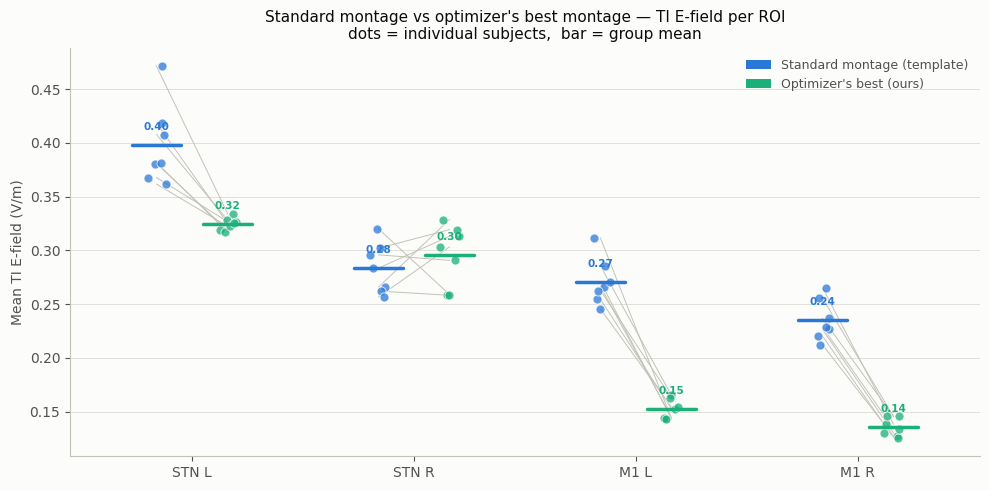

In [19]:
# Step 7: strip plot — Paul's montage (leadfield) vs optimizer's best montage
# Colors: reference palette slots 1 (blue=template) and 2 (aqua=our own), same as
# validate_personal_vs_pablo_results.ipynb's Step 12b.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

C_TEMPLATE = '#2a78d6'   # slot 1 blue  — Standard montage (template)
C_OURS     = '#1baf7a'   # slot 2 aqua  — optimizer's best montage (ours)

ROI_DISPLAY = {"STN_L": "STN L", "STN_R": "STN R", "M1_L": "M1 L", "M1_R": "M1 R"}
ROI_NAMES  = list(ROI_DISPLAY.keys())
ROI_LABELS = list(ROI_DISPLAY.values())

def _get_mean(results_dict, subject, roi_name):
    return results_dict.get(subject, {}).get(roi_name, {}).get("mean_V_m", float("nan"))

rng     = np.random.default_rng(42)
GRP_OFF = 0.16   # half-gap between Template / Ours clusters
JIT     = 0.045  # intra-cluster jitter half-width
MEAN_HW = 0.11   # half-width of the mean bar

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#fcfcfb')
ax.set_facecolor('#fcfcfb')

for xi, roi in enumerate(ROI_NAMES):
    # connect each subject's Template vs Ours with a thin line
    for s in SUBJECTS:
        tmpl_val = _get_mean(results_fast, s, roi)
        ours_val = _get_mean(results_optimizer, s, roi)
        if not np.isnan(tmpl_val) and not np.isnan(ours_val):
            ax.plot([xi - GRP_OFF, xi + GRP_OFF], [tmpl_val, ours_val],
                    color='#c3c2b7', linewidth=0.7, zorder=1)

    for color, sign, label, results_dict in [
        (C_TEMPLATE, -1, "Standard montage",     results_fast),
        (C_OURS,      1, "Optimizer's best",   results_optimizer),
    ]:
        vals = np.array([_get_mean(results_dict, s, roi) for s in SUBJECTS], dtype=float)
        valid = vals[~np.isnan(vals)]
        if len(valid) == 0:
            continue

        xc  = xi + sign * GRP_OFF
        jit = rng.uniform(-JIT, JIT, len(valid))
        ax.scatter(xc + jit, valid, color=color, s=42, alpha=0.75,
                   linewidths=0.7, edgecolors='white', zorder=3)

        mean_val = np.nanmean(vals)
        ax.plot([xc - MEAN_HW, xc + MEAN_HW], [mean_val, mean_val],
                color=color, linewidth=2.5, solid_capstyle='round', zorder=4)
        ax.text(xc, mean_val + 0.012, f'{mean_val:.2f}',
                ha='center', va='bottom', fontsize=7.5, color=color, fontweight='bold')

ax.set_xticks(range(len(ROI_NAMES)))
ax.set_xticklabels(ROI_LABELS, fontsize=10)
ax.set_xlim(-0.55, len(ROI_NAMES) - 0.45)
ax.set_ylabel('Mean TI E-field (V/m)', fontsize=10, color='#52514e')
ax.set_title("Standard montage vs optimizer's best montage — TI E-field per ROI\n"
             'dots = individual subjects,  bar = group mean',
             fontsize=11, color='#0b0b0b')
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color('#c3c2b7')
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(colors='#52514e')

legend_handles = [
    mpatches.Patch(facecolor=C_TEMPLATE, label="Standard montage (template)"),
    mpatches.Patch(facecolor=C_OURS,     label="Optimizer's best (ours)"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=9,
          labelcolor='#52514e', loc='upper right')

plt.tight_layout()
plt.show()


## Step 8: export for the data into csv for easy access

In [22]:
# Step 8: wide-format comparison table (one row per subject x variant),
# electrodes/currents included so the CSV is self-contained — exported next to
# the other per-project outputs under derivatives/SimNIBS/.
import pandas as pd

rows = []
for subject in SUBJECTS:

    # --- Standard Montage row ---
    row = {
        "subject": subject, "variant": "Standard Montage",
        "ch1_plus": MONTAGE["ch1"]["plus"], "ch1_minus": MONTAGE["ch1"]["minus"],
        "ch1_current_mA": MONTAGE["ch1"]["current_mA"],
        "ch2_plus": MONTAGE["ch2"]["plus"], "ch2_minus": MONTAGE["ch2"]["minus"],
        "ch2_current_mA": MONTAGE["ch2"]["current_mA"],
    }
    has_data = False
    for roi_name in ROIS:
        stats = results_fast.get(subject, {}).get(roi_name)
        if stats:
            has_data = True
            row[f"{roi_name}_mean_V_m"] = stats["mean_V_m"]
            row[f"{roi_name}_max_V_m"] = stats["max_V_m"]
            row[f"{roi_name}_n_elements"] = stats["n_elements"]
    if has_data:
        rows.append(row)

    # --- Optimizer's best row ---
    bm = optimizer_best_montage.get(subject)
    if bm:
        row = {
            "subject": subject, "variant": "Optimizer's best",
            "ch1_plus": bm["ch1_plus"], "ch1_minus": bm["ch1_minus"],
            "ch1_current_mA": bm["current_mA"],
            "ch2_plus": bm["ch2_plus"], "ch2_minus": bm["ch2_minus"],
            "ch2_current_mA": bm["current_mA"],
        }
        has_data = False
        for roi_name in ROIS:
            stats = results_optimizer.get(subject, {}).get(roi_name)
            if stats:
                has_data = True
                row[f"{roi_name}_mean_V_m"] = stats["mean_V_m"]
                row[f"{roi_name}_max_V_m"] = stats["max_V_m"]
                row[f"{roi_name}_n_elements"] = stats["n_elements"]
        if has_data:
            rows.append(row)

COMPARISON_RESULTS_DIR = os.path.join(PROJECT_DIR, "Paul_Validation_E_Fields", "52Y")

comparison_df = pd.DataFrame(rows)

out_csv = os.path.join(COMPARISON_RESULTS_DIR, "standard_vs_optimizer_comparison.csv")
comparison_df.to_csv(out_csv, index=False)
print(f"-> {out_csv}  ({len(comparison_df)} rows)")
comparison_df

-> D:\MINDS_Project_Karim\BIDS_TI_Toolbox\Paul_Validation_E_Fields\52Y\standard_vs_optimizer_comparison.csv  (14 rows)


,subject,variant,ch1_plus,ch1_minus,ch1_current_mA,ch2_plus,ch2_minus,ch2_current_mA,STN_L_mean_V_m,STN_L_max_V_m,STN_L_n_elements,STN_R_mean_V_m,STN_R_max_V_m,STN_R_n_elements,M1_L_mean_V_m,M1_L_max_V_m,M1_L_n_elements,M1_R_mean_V_m,M1_R_max_V_m,M1_R_n_elements
0,52Y03,Standard Montage,AF4,FT9,1.69,P9,CP2,1.89,0.471153,0.509047,12,0.320047,0.371264,29,0.311547,0.741282,23834,0.265515,0.652704,24192
1,52Y03,Optimizer's best,F7,F3,2.00,FT10,C6,2.00,0.334251,0.362185,12,0.258960,0.316726,29,0.143556,0.322327,23834,0.138698,0.365264,24192
2,52Y04,Standard Montage,AF4,FT9,1.69,P9,CP2,1.89,0.380670,0.433125,14,0.283567,0.340763,16,0.266441,0.591191,19757,0.255547,0.547707,22546
3,52Y04,Optimizer's best,P9,PO3,2.00,C6,PO10,2.00,0.318592,0.369364,14,0.313221,0.444063,16,0.144546,0.291940,19757,0.145864,0.289352,22546
4,52Y05,Standard Montage,AF4,FT9,1.69,P9,CP2,1.89,0.407714,0.451043,16,0.302041,0.332405,12,0.285566,0.775105,23899,0.226628,0.615521,23067
5,52Y05,Optimizer's best,F7,C5,2.00,FT8,C4,2.00,0.328148,0.410136,16,0.319353,0.353880,12,0.165226,0.383132,23899,0.130289,0.319440,23067
6,52Y08,Standard Montage,AF4,FT9,1.69,P9,CP2,1.89,0.381593,0.420711,11,0.295921,0.328509,15,0.270796,0.648171,23067,0.236766,0.574979,23801
7,52Y08,Optimizer's best,F7,FC3,2.00,FT10,CP6,2.00,0.317032,0.364137,11,0.290737,0.329020,15,0.143501,0.265001,23067,0.145874,0.322979,23801
8,52Y09,Standard Montage,AF4,FT9,1.69,P9,CP2,1.89,0.367686,0.398558,21,0.266001,0.306757,19,0.254457,0.576121,22239,0.212306,0.529360,23450
9,52Y09,Optimizer's best,CP5,PO9,2.00,P4,PO10,2.00,0.326837,0.360011,21,0.328700,0.379898,19,0.152877,0.328268,22239,0.127449,0.270712,23450
